**Problem Statement**
* **Business Context:**
Yulu is India’s leading micro-mobility service provider, offering shared electric bicycles for first and last-mile commuting. However, the company has recently experienced a dip in revenues, prompting the need to understand what factors affect the demand for its services.

* **Objective:**
To identify and analyze the key variables that significantly impact the demand for shared electric cycles in the Indian market. By understanding these factors, Yulu can take data-driven business decisions to boost demand and improve revenue.

* **Problem Statement:**
To explore and analyze the dataset to understand the relationship between demand (count of rentals) and other influencing factors such as season, weather, temperature, working day, and holiday status. Use EDA and statistical hypothesis testing to identify significant patterns and dependencies that can influence business strategy.

* **Goals:**
  * Understand the structure and distribution of the dataset using EDA.
  * Identify if factors like season, weather, or working day have a statistically significant impact on electric cycle demand.
  * Evaluate interdependence between predictor variables such as weather and season.

* **Expected Business Outcome:**
Actionable insights to optimize Yulu zone deployments, run targeted promotions, and strategically manage fleet size based on expected demand patterns.

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving bike_sharing.csv to bike_sharing.csv


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

df = pd.read_csv('bike_sharing.csv')

# Quick overview
print("Dataset Shape:", df.shape)
print("\nData Types & Non-Null Counts:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())



Dataset Shape: (10886, 12)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB
None

Statistical Summary:
             season       holiday    workingday       weather         temp  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.00000   
mean       

# Observations:
* We have 10886 rows, 12 columns which is decent size for statistical analysis.
* No missing values thus no need for imputation.
* datetime is object type so, we can extract features like hour, day, month later.
* season, holiday, workingday, weather are categorical but stored as numbers	we should convert to category dtype for clarity and plotting.
* count, casual, registered are numerical and	count is our target variable.
* All other columns are continuous	We will analyze their effect on count

# Data Type Conversion & Datetime Parsing

In [ ]:
# Convert categorical variables to category dtype
cat_cols = ['season', 'holiday', 'workingday', 'weather']
for col in cat_cols:
    df[col] = df[col].astype('category')

# Convert 'datetime' column to actual datetime object
df['datetime'] = pd.to_datetime(df['datetime'])

# Extract useful time features for later use
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['weekday'] = df['datetime'].dt.weekday


# Univariate Analysis

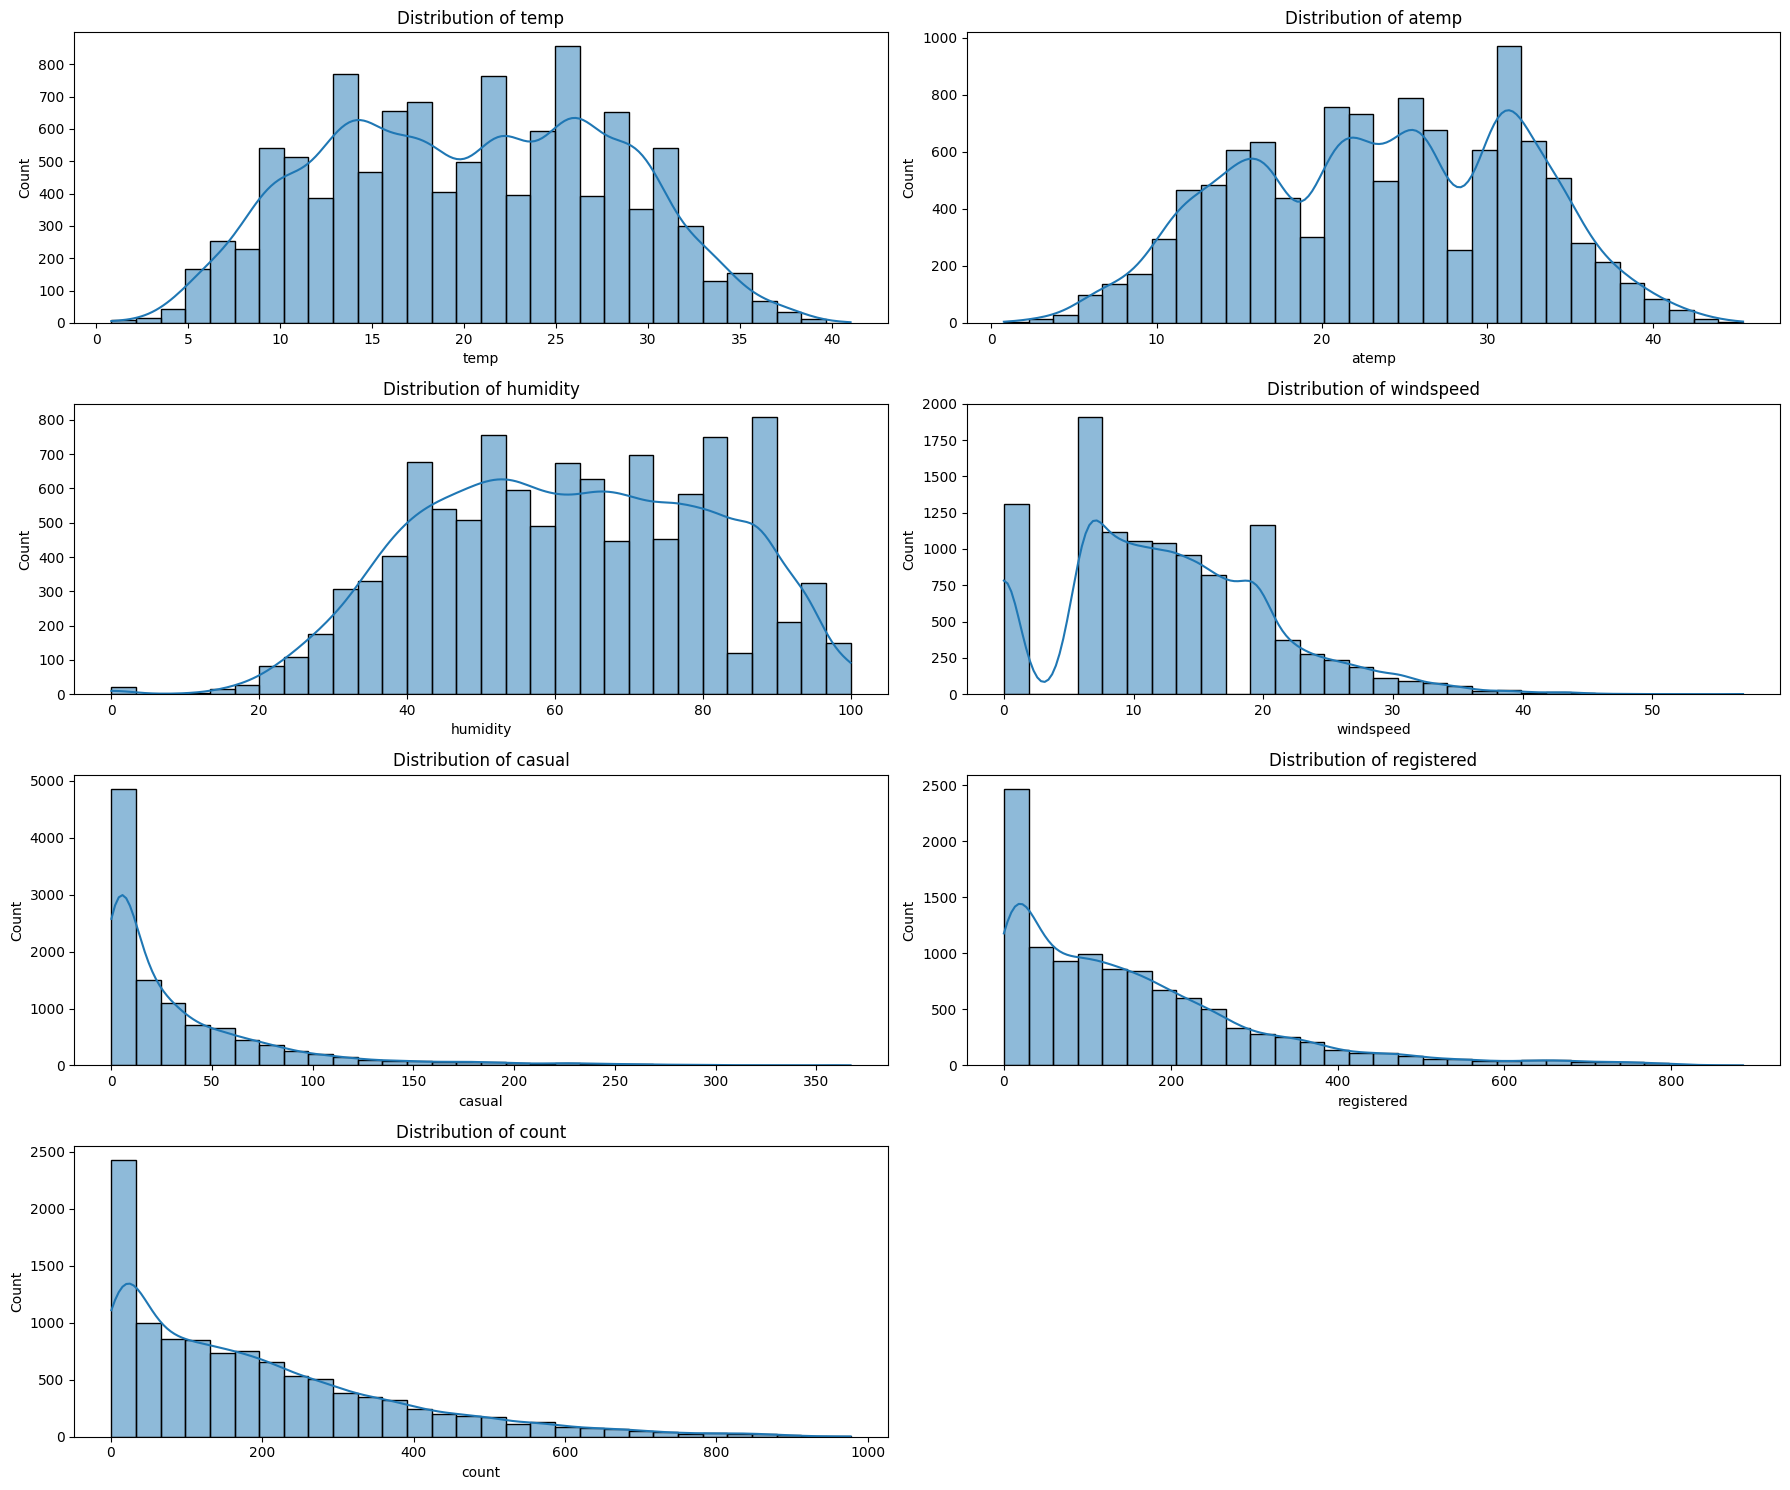

In [ ]:
# List of continuous variables
cont_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

# Plot distribution plots
plt.figure(figsize=(18, 15))
for i, col in enumerate(cont_cols, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}', fontsize=12)
plt.tight_layout()
plt.show()


temp: Normal-like, peaks at 20–25°C
*  Most rides happen in comfortable temperatures.

atemp: Slightly multi-modal
* Perceived temperature affects user behavior.

humidity: Right-skewed, many days >60%
* High humidity may reduce usage.

windspeed: Right-skewed, mostly low
* Wind has little effect except on rare windy days.

casual: Heavy right-skew, peak near zero
* Many one-time or rare users.

registered: Right-skewed but more spread
* Frequent users drive consistent demand.

count: Right-skewed, mostly under 400
* Demand is usually moderate, spikes are rare.

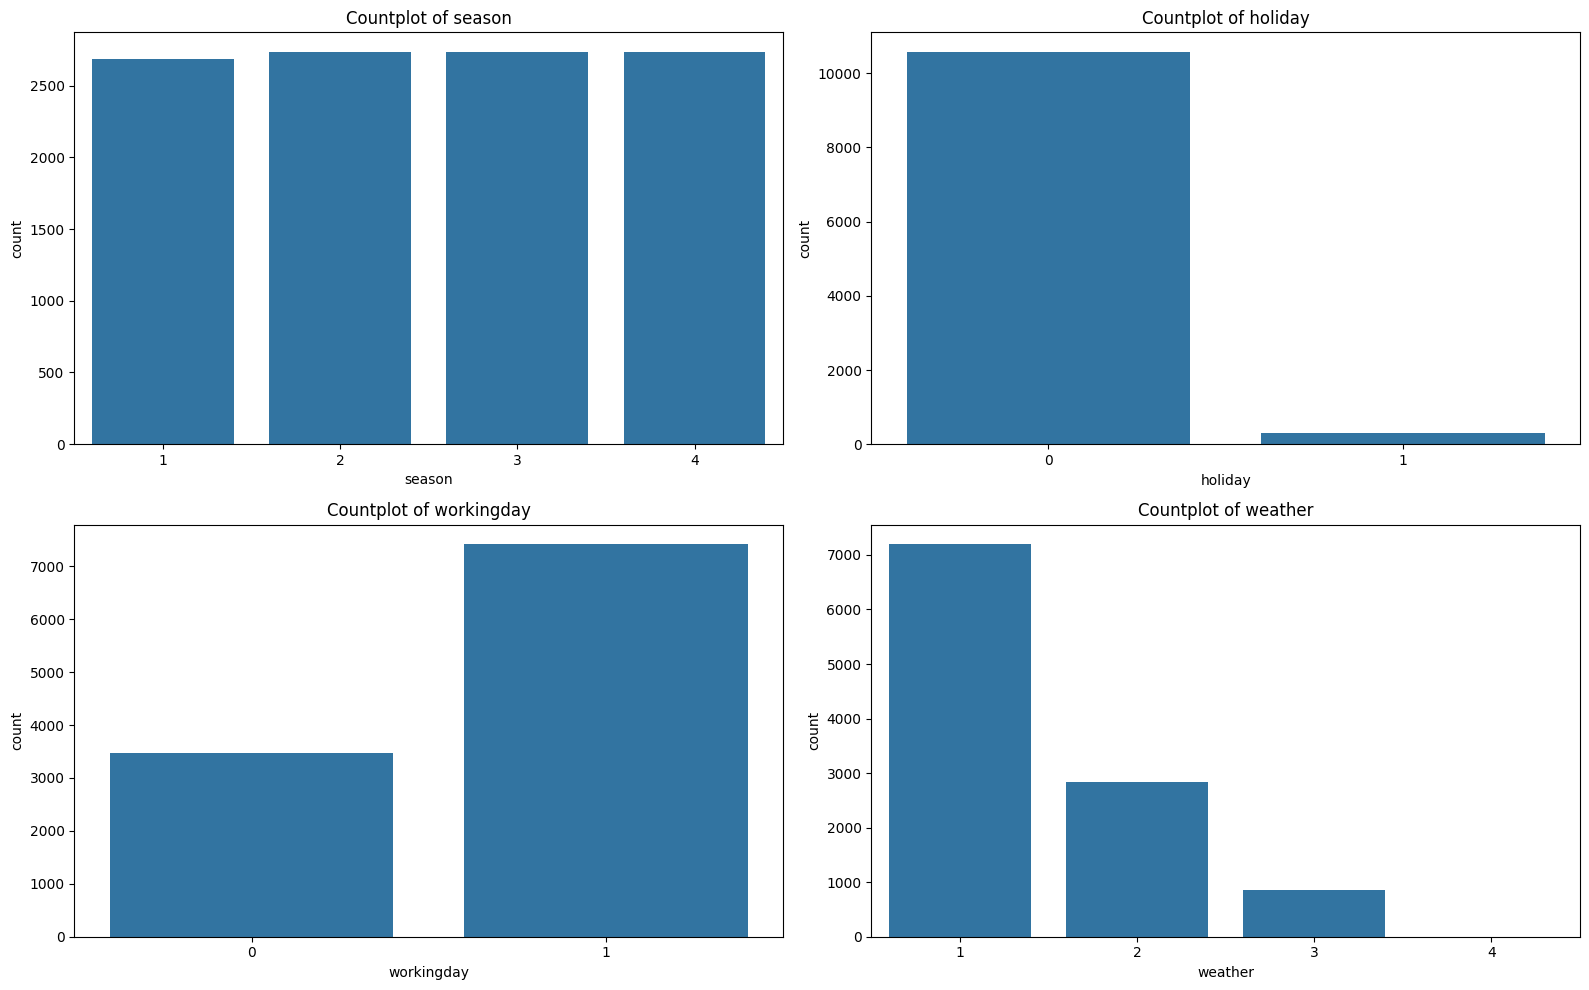

In [ ]:
# List of categorical variables
cat_cols = ['season', 'holiday', 'workingday', 'weather']

# Plot countplots
plt.figure(figsize=(16, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Countplot of {col}', fontsize=12)
plt.tight_layout()
plt.show()


**Insights from the plot**
1. season
  * All four seasons (1 to 4) are almost equally represented.

  * The dataset is well-balanced seasonally, which allows for fair seasonal comparisons.

2. holiday
  * Very few days are holidays (holiday = 1).

    Business Insight: Since holidays are rare, their impact on demand may not be strong or may require deeper analysis.

3. workingday
  * Around 70% of the data represents working days (workingday = 1).

    Business Insight: More data is available for working patterns—important for commuter demand analysis.

4. weather
  * Majority of observations fall under weather category 1 (Clear or Partly Cloudy).

  * Very few records for bad weather (categories 3 and 4).

    Business Insight: Demand analysis under extreme weather may be limited due to data sparsity.

# Categorical Variables vs count (Target)

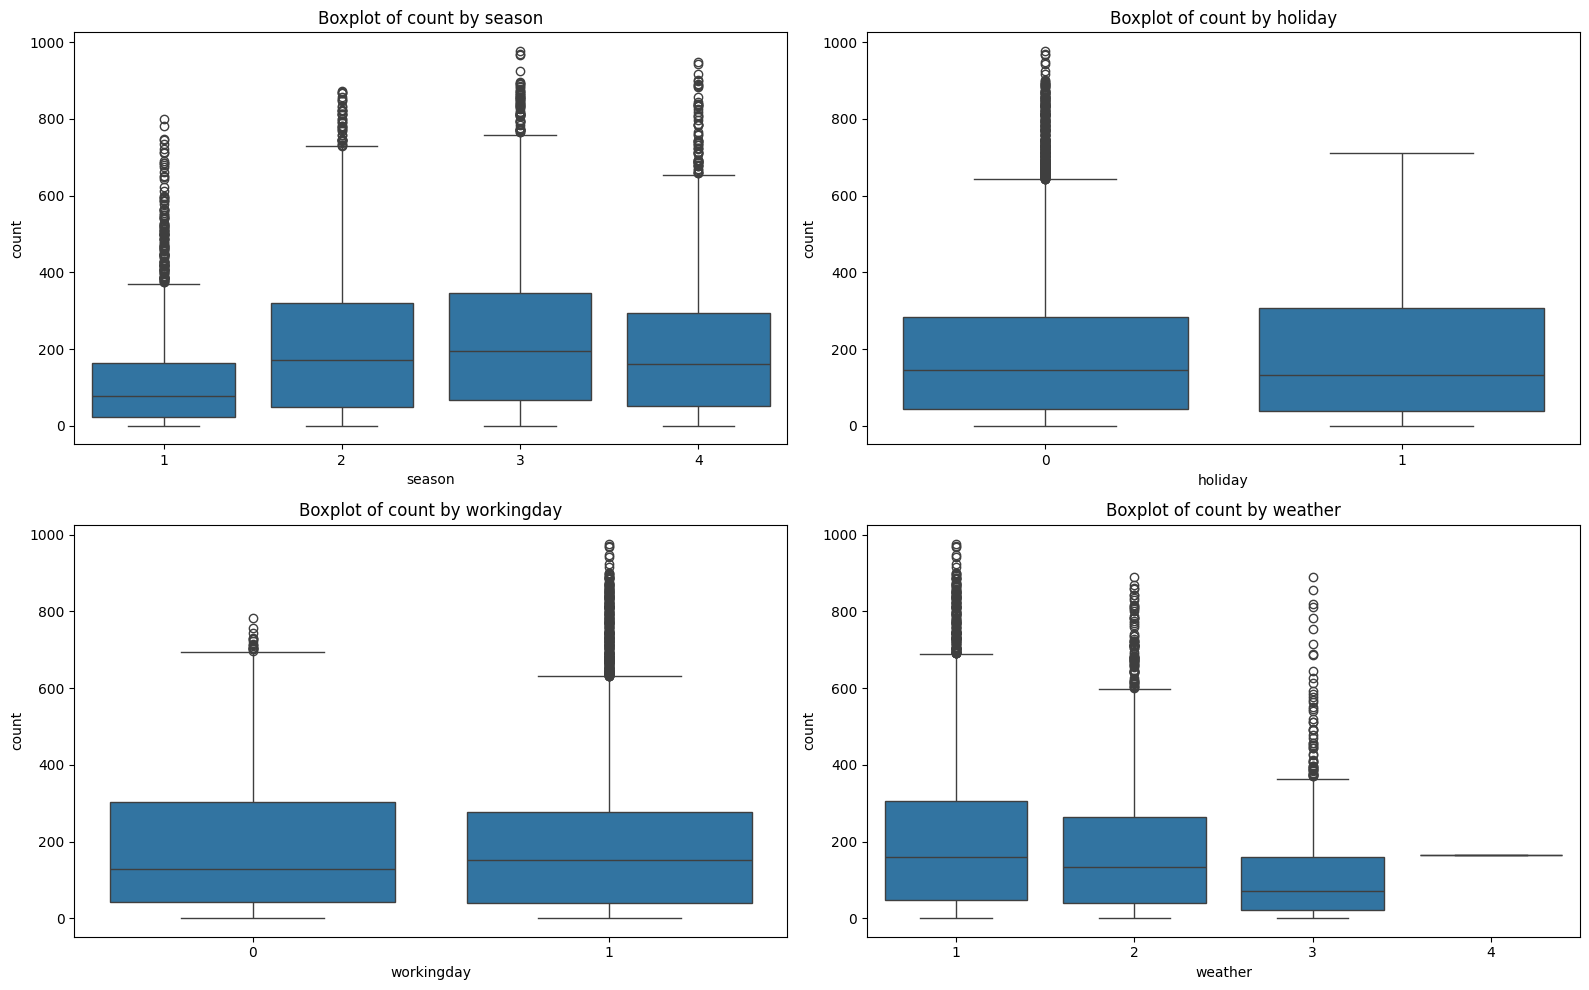

In [ ]:
categorical_vars = ['season', 'holiday', 'workingday', 'weather']

plt.figure(figsize=(16, 10))
for i, var in enumerate(categorical_vars):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x=var, y='count')
    plt.title(f'Boxplot of count by {var}')
plt.tight_layout()
plt.show()


# Bivariate Insights: Categorical Features vs count

* Season:

  * Demand is higher in seasons 2 and 3 (Spring and Summer).

  * Business Insight: Good weather seasons see more rides, likely due to favorable riding conditions.

* Holiday:

  * Slightly lower demand on holidays (1) than non-holidays (0).

  * Business Insight: More rides on working days—possibly due to commute-related usage.

* Working Day:

    * Higher median count on working days (1).

  *  Business Insight: Commuters significantly drive demand on workdays.

* Weather:

    * Demand is highest in weather condition 1 (Clear/Few clouds).

    * Drops sharply as weather worsens (2, 3, and especially 4).

    * Business Insight: Bad weather negatively affects ride demand.

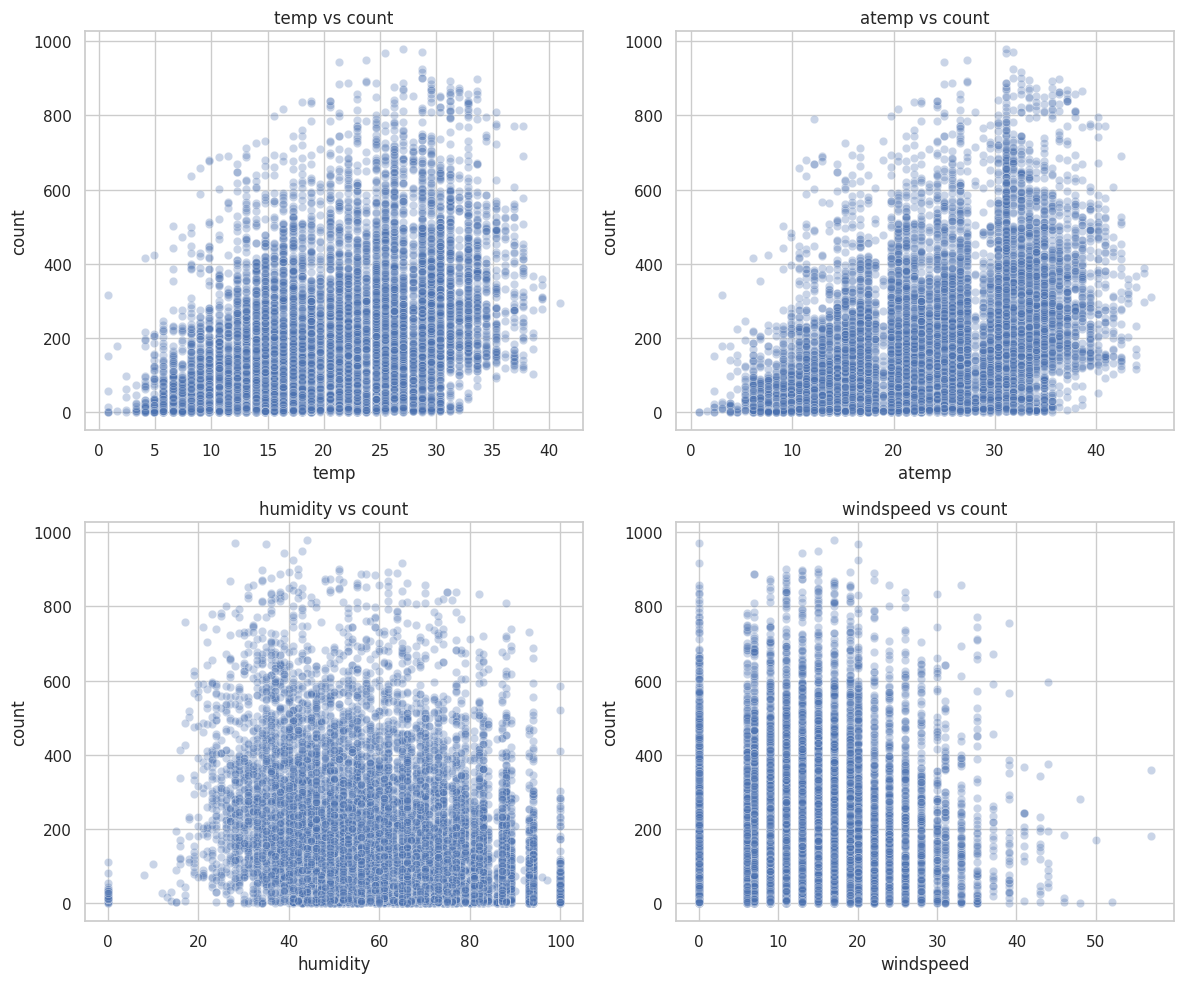

In [ ]:
plt.figure(figsize=(12, 10))
sns.set(style="whitegrid")

# Continuous variables to compare with 'count'
continuous_vars = ['temp', 'atemp', 'humidity', 'windspeed']

# Plotting
for i, var in enumerate(continuous_vars):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(data=df, x=var, y='count', alpha=0.3)
    plt.title(f'{var} vs count')

plt.tight_layout()
plt.show()


**Insights:**
* Temp vs Count: Count increases with temperature up to ~30°C, then slightly drops — optimal riding temp.

* Atemp vs Count: Follows a similar pattern as temp — perceived warmth impacts demand.

* Humidity vs Count: Higher humidity slightly lowers demand — discomfort may reduce rides.

* Windspeed vs Count: Weak/no clear trend — windspeed likely not a major factor.





# T Test

**Objective:** Check if there is a significant difference in mean ride count between holidays and non-holidays.

**Hypotheses:**
**Null Hypothesis (H₀):**
There is no significant difference in average ride count between holidays and non-holidays.

**Alternative Hypothesis (H₁):**
There is a significant difference in average ride count between holidays and non-holidays.



In [ ]:
from scipy.stats import ttest_ind

# Separate ride counts based on holiday status
holiday_counts = df[df['holiday'] == 1]['count']
non_holiday_counts = df[df['holiday'] == 0]['count']

# Perform independent t-test
t_stat, p_value = ttest_ind(holiday_counts, non_holiday_counts)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")


T-statistic: -0.5626
P-value: 0.5737


T-Test: holiday vs count

* T-statistic: -0.5626

* P-value: 0.5737 (> 0.05)

**Insight:**

* There is no significant difference in ride count between holidays and non-holidays.

* Business Implication: Demand is fairly consistent regardless of holidays; holiday status doesn't impact ride volume much.

# T-Test: workingday vs count
**Objective:**
Check if the average number of rides differs significantly between working days and non-working days.

**Hypotheses:**

**Null Hypothesis (H₀):**
There is no significant difference in ride count between working and non-working days.

**Alternative Hypothesis (H₁):**
There is a significant difference in ride count between working and non-working days.

In [ ]:
# Separate ride counts based on workingday status
workingday_counts = df[df['workingday'] == 1]['count']
non_workingday_counts = df[df['workingday'] == 0]['count']

# Perform independent t-test
t_stat, p_value = ttest_ind(workingday_counts, non_workingday_counts)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")


T-statistic: 1.2096
P-value: 0.2264


T-Test: workingday vs count

T-statistic: 1.2096

P-value: 0.2264 (> 0.05)

**Insight:**

* There is no statistically significant difference in ride counts between working and non-working days.

* Business Implication: Ride demand stays relatively stable regardless of the workday status. This could mean people use Yulu for both commuting and leisure.

# ANOVA: season vs count
**Objective:**
Check whether the mean ride count is significantly different across the 4 seasons.

**Hypotheses:**

**Null Hypothesis (H₀):**
The mean ride count is the same across all seasons.

**Alternative Hypothesis (H₁):**
At least one season has a different mean ride count.

In [ ]:
from scipy.stats import f_oneway

# Split data by season
spring = df[df['season'] == 1]['count']
summer = df[df['season'] == 2]['count']
fall   = df[df['season'] == 3]['count']
winter = df[df['season'] == 4]['count']

# Perform ANOVA
f_stat, p_value = f_oneway(spring, summer, fall, winter)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")


F-statistic: 236.9467
P-value: 0.0000


ANOVA Test: season vs count

F-statistic: 236.9467

P-value: 0.0000 (< 0.05)

**Insight:**
* There is a statistically significant difference in ride counts across seasons.

* Business Implication: Demand varies by season, so Yulu should consider seasonal strategies like:

  * Fleet redistribution

  * Maintenance planning

  * Seasonal pricing or promotions

# ANOVA: weather vs count
**Objective:**
Check whether the mean ride count is significantly different across different weather conditions (1 to 4).

**Hypotheses:**
**H₀ (Null):**
The mean ride count is same across all weather conditions.

**H₁ (Alt):**
At least one weather condition has a different mean ride count.



In [ ]:
# Group counts by weather category
weather_1 = df[df['weather'] == 1]['count']
weather_2 = df[df['weather'] == 2]['count']
weather_3 = df[df['weather'] == 3]['count']
weather_4 = df[df['weather'] == 4]['count']  # May have very few entries

# Perform ANOVA
f_stat, p_value = f_oneway(weather_1, weather_2, weather_3, weather_4)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")


F-statistic: 65.5302
P-value: 0.0000


ANOVA Test: weather vs count

F-statistic: 65.5302

P-value: 0.0000 (< 0.05)

**Insight:**

* There is a statistically significant difference in ride counts across different weather conditions.

* Business Implication:
Yulu should factor in weather forecasts while:

  * Planning fleet availability

  * Offering weather-based discounts

  * Adjusting user expectations during poor weather

# Chi-Square Test: weather vs season
**Objective:**
Check whether weather conditions are independent of seasons.

**Hypotheses:**

**H₀ (Null):**
Weather is independent of season.

**H₁ (Alternate):**
Weather is dependent on season.

In [ ]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['season'], df['weather'])

# Perform Chi-Square Test
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4f}")


Chi-Square Statistic: 49.1587
P-value: 0.0000


Chi-Square Test: weather vs season

Chi-Square Statistic: 49.1587

P-value: 0.0000 (< 0.05)

**Insight:**

* Reject Null Hypothesis So Weather is dependent on season.

* Business Implication:

  * Seasonal changes influence weather, which indirectly affects ride demand.

  * Yulu can plan seasonal demand strategies and fleet optimization accordingly.

# Confidence Interval for Mean Demand

In [ ]:
import scipy.stats as stats
import numpy as np

# 95% Confidence Interval
mean_count = df['count'].mean()
sem_count = stats.sem(df['count'])  # Standard error of mean
ci = stats.t.interval(0.95, len(df['count'])-1, loc=mean_count, scale=sem_count)

print(f"Mean Demand: {mean_count:.2f}")
print(f"95% Confidence Interval for Mean Demand: {ci}")


Mean Demand: 191.57
95% Confidence Interval for Mean Demand: (np.float64(188.17093356334237), np.float64(194.9773302617541))


* Demand shows a clear upward trend from January to June, peaking in June (~240 average rentals/day).

* After June, there's a gradual decline, but demand stays strong until October.

* Lowest demand is in January, likely due to cold weather.

**Implication:** Seasonality is a major driver, so marketing, maintenance, and fleet management should be adjusted month-wise.

Line Plot: Average Daily Demand by Month

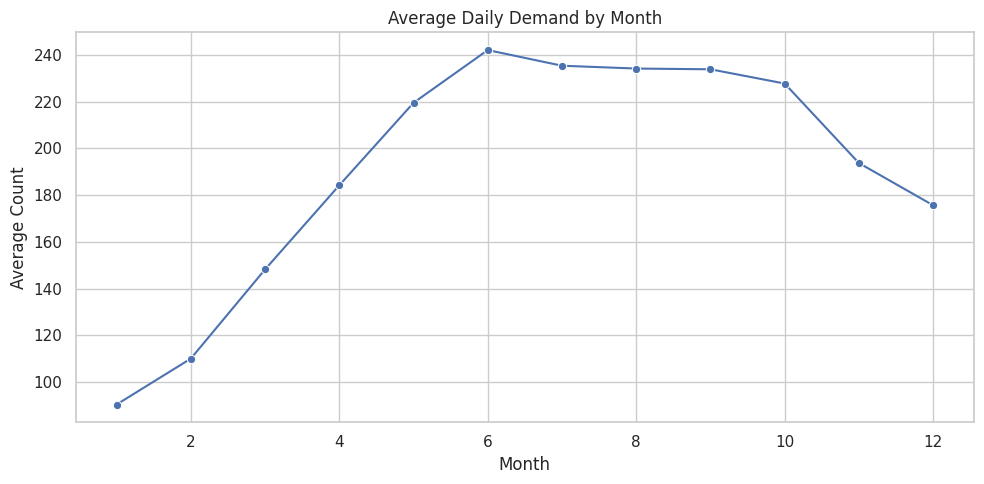

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month

monthly_avg = df.groupby('month')['count'].mean()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o')
plt.title("Average Daily Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Count")
plt.grid(True)
plt.tight_layout()
plt.show()


* Demand is fairly consistent across weekdays, highest on Friday & Thursday (~198).

* Sunday has the lowest demand (~180).

* This may suggest:

  * Higher weekday utility usage (commuting).

  * Lower leisure demand on Sundays.

**Implication:** No need for major operational shifts per weekday, but slightly reduce availability on Sundays.

Bar Plot: Average Demand by Weekday

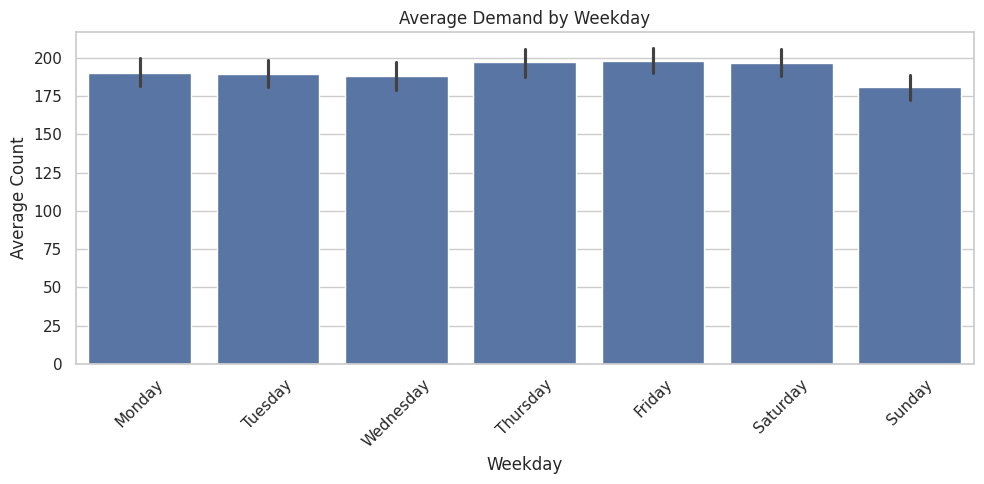

In [ ]:
df['weekday'] = df['datetime'].dt.day_name()

plt.figure(figsize=(10, 5))
sns.barplot(x='weekday', y='count', data=df, estimator=np.mean, order=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title("Average Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


* Mean Daily Demand: ~191.57 cycles.

* 95% Confidence Interval: (188.17, 194.98)

**Interpretation:**

  * We are 95% confident that the true average daily demand lies between ~188 and ~195.

  * The narrow range suggests consistent average demand with low uncertainty.

**Implication:** This can be used to predict minimum fleet size required daily.

 # Business Recommendations

* Scale up bike availability in May–July, especially in June.

* Adjust fleet deployment for Thursday–Saturday peaks.

* Plan promotional campaigns in off-peak months (Jan, Dec).

* Use mean demand (191/day) and CI (188–195) to plan average daily fleet.

* Perform maintenance on Sundays if demand is lower.